In [16]:
# Load the saved two-stage datasets
import pandas as pd
from pathlib import Path

MODEL_DATA_PATH = Path("../model_datasets_two_stage")

X_train = pd.read_parquet(MODEL_DATA_PATH / "X_train_scaled.parquet")
X_val   = pd.read_parquet(MODEL_DATA_PATH / "X_val_scaled.parquet")
X_test  = pd.read_parquet(MODEL_DATA_PATH / "X_test_scaled.parquet")

y_train_m = pd.read_parquet(MODEL_DATA_PATH / "y_train_m.parquet")["moneyness_encoded"]
y_val_m   = pd.read_parquet(MODEL_DATA_PATH / "y_val_m.parquet")["moneyness_encoded"]
y_test_m  = pd.read_parquet(MODEL_DATA_PATH / "y_test_m.parquet")["moneyness_encoded"]

y_train_d = pd.read_parquet(MODEL_DATA_PATH / "y_train_d.parquet")["dte_encoded"]
y_val_d   = pd.read_parquet(MODEL_DATA_PATH / "y_val_d.parquet")["dte_encoded"]
y_test_d  = pd.read_parquet(MODEL_DATA_PATH / "y_test_d.parquet")["dte_encoded"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train_m:", y_train_m.shape)
print("y_train_d:", y_train_d.shape)

X_train: (33736, 81)
X_val: (5010, 81)
X_test: (5020, 81)
y_train_m: (33736,)
y_train_d: (33736,)


In [17]:
# Inspect target distributions

print("Moneyness train distribution:")
print(y_train_m.value_counts().sort_index())

print("\nDTE train distribution:")
print(y_train_d.value_counts().sort_index())

Moneyness train distribution:
moneyness_encoded
0    25746
1     3862
2     4128
Name: count, dtype: int64

DTE train distribution:
dte_encoded
0    11299
1     7874
2    14563
Name: count, dtype: int64


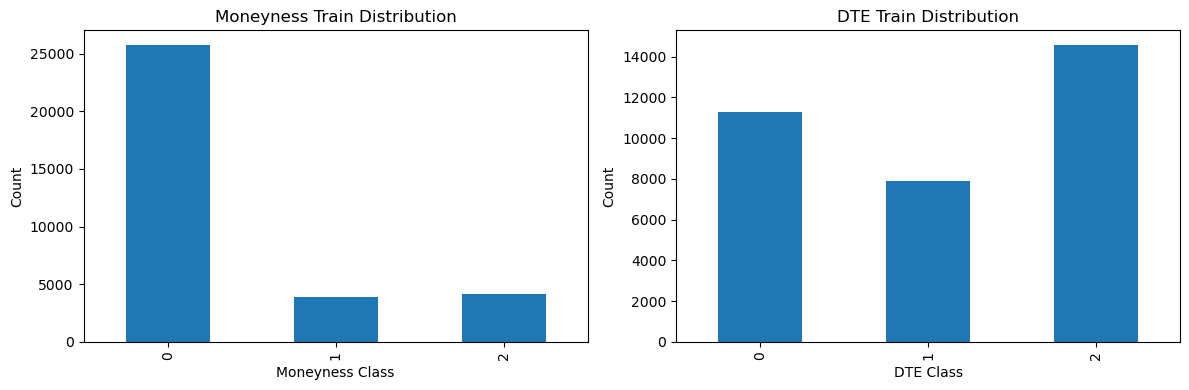

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train_m.value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Moneyness Train Distribution")
axes[0].set_xlabel("Moneyness Class")
axes[0].set_ylabel("Count")

y_train_d.value_counts().sort_index().plot(kind="bar", ax=axes[1], title="DTE Train Distribution")
axes[1].set_xlabel("DTE Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Baseline XGBoost for Moneyness

In [19]:
from xgboost import XGBClassifier

num_classes_m = y_train_m.nunique()

xgb_m = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes_m,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    early_stopping_rounds=30
)

xgb_m.fit(
    X_train,
    y_train_m,
    eval_set=[(X_train, y_train_m), (X_val, y_val_m)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,30
,enable_categorical,False
,eval_metric,'mlogloss'


In [20]:
# Baseline XGBoost for DTE

num_classes_d = y_train_d.nunique()

xgb_d = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes_d,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    early_stopping_rounds=30
)

xgb_d.fit(
    X_train,
    y_train_d,
    eval_set=[(X_train, y_train_d), (X_val, y_val_d)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,30
,enable_categorical,False
,eval_metric,'mlogloss'


In [21]:
# Evaluate each stage separately
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report

# hard predictions
y_pred_m = xgb_m.predict(X_test)
y_pred_d = xgb_d.predict(X_test)

print("=== Moneyness Model ===")
print("Accuracy:", accuracy_score(y_test_m, y_pred_m))
print("Macro F1:", f1_score(y_test_m, y_pred_m, average="macro"))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_m, y_pred_m))
print(classification_report(y_test_m, y_pred_m, zero_division=0))

print("\n=== DTE Model ===")
print("Accuracy:", accuracy_score(y_test_d, y_pred_d))
print("Macro F1:", f1_score(y_test_d, y_pred_d, average="macro"))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_d, y_pred_d))
print(classification_report(y_test_d, y_pred_d, zero_division=0))

=== Moneyness Model ===
Accuracy: 0.2711155378486056
Macro F1: 0.14219296870918874
Balanced Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

           0       0.27      1.00      0.43      1361
           1       0.00      0.00      0.00      2886
           2       0.00      0.00      0.00       773

    accuracy                           0.27      5020
   macro avg       0.09      0.33      0.14      5020
weighted avg       0.07      0.27      0.12      5020


=== DTE Model ===
Accuracy: 0.6374501992031872
Macro F1: 0.310113645379869
Balanced Accuracy: 0.34470844484716573
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       933
           1       0.17      0.14      0.15       617
           2       0.69      0.90      0.78      3470

    accuracy                           0.64      5020
   macro avg       0.29      0.34      0.31      5020
weighted avg       0.50      0.64      0.56      5020



In [22]:
# get predicted probabilities
proba_m = xgb_m.predict_proba(X_test)
proba_d = xgb_d.predict_proba(X_test)

print("proba_m shape:", proba_m.shape)
print("proba_d shape:", proba_d.shape)

proba_m shape: (5020, 3)
proba_d shape: (5020, 3)


In [23]:
# Define class name mappings
moneyness_map = {
    0: "ATM",
    1: "OTM10",
    2: "OTM5"
}

dte_map = {
    0: "30",
    1: "60",
    2: "90"
}

In [24]:
print("Unique moneyness classes in train:", sorted(y_train_m.unique()))
print("Unique dte classes in train:", sorted(y_train_d.unique()))

Unique moneyness classes in train: [np.int64(0), np.int64(1), np.int64(2)]
Unique dte classes in train: [np.int64(0), np.int64(1), np.int64(2)]


In [25]:
# Build true final bucket labels for test set
full_df = pd.read_parquet("../data/clean/daily_stock_optimal_bucket_two_stage_modeling.parquet")
full_df["date"] = pd.to_datetime(full_df["date"])
full_df = full_df.sort_values(["symbol", "date"]).reset_index(drop=True)

test_full = full_df[full_df["date"] >= "2024-01-01"].copy()
y_test_bucket_true = test_full["optimal_bucket"].reset_index(drop=True)

print(y_test_bucket_true.head())

0    ATM_30
1    ATM_30
2    ATM_30
3    ATM_30
4    ATM_30
Name: optimal_bucket, dtype: object


In [26]:
# Combine probabilities into final predictions
combined_preds = []

for i in range(len(X_test)):
    best_bucket = None
    best_score = -1

    for m_idx, m_name in moneyness_map.items():
        for d_idx, d_name in dte_map.items():
            score = proba_m[i, m_idx] * proba_d[i, d_idx]
            bucket = f"{m_name}_{d_name}"

            if score > best_score:
                best_score = score
                best_bucket = bucket

    combined_preds.append(best_bucket)

combined_preds = pd.Series(combined_preds)

print(combined_preds.head())

0    ATM_90
1    ATM_90
2    ATM_90
3    ATM_90
4    ATM_90
dtype: object


In [27]:
# Evaluate final combined bucket prediction

from sklearn.metrics import classification_report, accuracy_score, f1_score

print("=== Final Combined Bucket Prediction ===")
print("Accuracy:", accuracy_score(y_test_bucket_true, combined_preds))
print("Macro F1:", f1_score(y_test_bucket_true, combined_preds, average="macro"))

print(classification_report(y_test_bucket_true, combined_preds, zero_division=0))

=== Final Combined Bucket Prediction ===
Accuracy: 0.15856573705179283
Macro F1: 0.04806756711084073
              precision    recall  f1-score   support

      ATM_30       0.00      0.00      0.00       501
      ATM_60       0.08      0.67      0.15        63
      ATM_90       0.17      0.95      0.28       797
    OTM10_30       0.00      0.00      0.00       306
    OTM10_60       0.00      0.00      0.00       410
    OTM10_90       0.00      0.00      0.00      2170
     OTM5_30       0.00      0.00      0.00       126
     OTM5_60       0.00      0.00      0.00       144
     OTM5_90       0.00      0.00      0.00       503

    accuracy                           0.16      5020
   macro avg       0.03      0.18      0.05      5020
weighted avg       0.03      0.16      0.05      5020



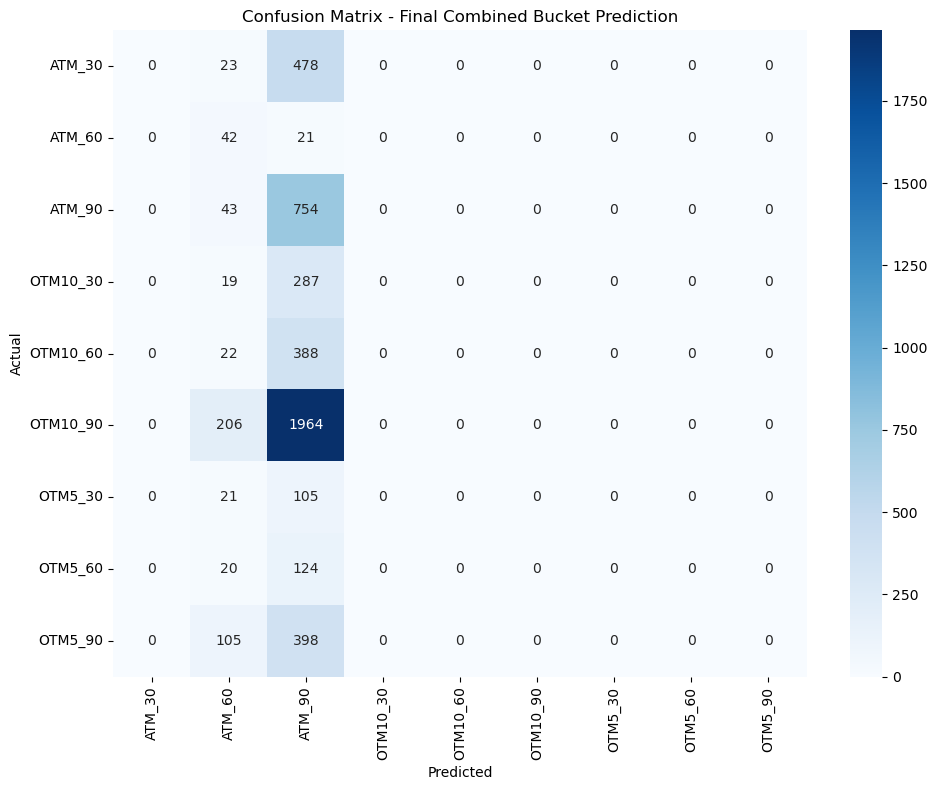

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

bucket_labels_sorted = sorted(y_test_bucket_true.unique())
cm = confusion_matrix(y_test_bucket_true, combined_preds, labels=bucket_labels_sorted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=bucket_labels_sorted,
            yticklabels=bucket_labels_sorted)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Combined Bucket Prediction")
plt.tight_layout()
plt.show()

In [29]:
hard_combined_preds = pd.Series([
    f"{moneyness_map[m]}_{dte_map[d]}"
    for m, d in zip(y_pred_m, y_pred_d)
])

print("=== Hard Combined Prediction ===")
print("Accuracy:", accuracy_score(y_test_bucket_true, hard_combined_preds))
print("Macro F1:", f1_score(y_test_bucket_true, hard_combined_preds, average="macro"))

=== Hard Combined Prediction ===
Accuracy: 0.15856573705179283
Macro F1: 0.04806756711084073
